In [2]:
# Must run before numpy/torch/sklearn/faiss import their own OpenMP runtime.
# Multiple bundled libomp.dylib copies (torch + sklearn + faiss) crash the
# kernel on macOS without this.
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


# RAG Foundations: Embeddings, Vector Search, and Chunking
<!-- 
A hands-on notebook to build intuition for the three building blocks of a
retrieval pipeline **before** you wire up a full RAG system.

**Run this locally** (not in this chat) — it needs internet access to
download a model and install packages the first time.

```bash
#pip install sentence-transformers faiss-cpu numpy matplotlib scikit-learn
# optional, only if you want to try the OpenAI embedding too:
#pip install openai
```

Sections:
1. What an embedding actually is (toy vectors, no model needed)
2. Cosine similarity vs. dot product — and when they differ
3. Real embeddings with `sentence-transformers/all-MiniLM-L6-v2` (+ optional OpenAI)
4. Vector indexes: Flat, IVF, HNSW with FAISS
5. Chunking strategies compared side-by-side
6. Putting it together: a tiny end-to-end retrieval example -->


## 1. What is an embedding?

An embedding is just a list of numbers (a vector) that represents a piece of
text such that **texts with similar meaning end up as vectors that are close
together in space**. Nothing more mystical than that — the model has learned
a mapping from language to geometry.

Before touching a real model, let's build a *toy* embedding space by hand so
the geometry is transparent. We'll represent 5 words as hand-picked 2D
vectors along two made-up axes: "royalty" and "gender".


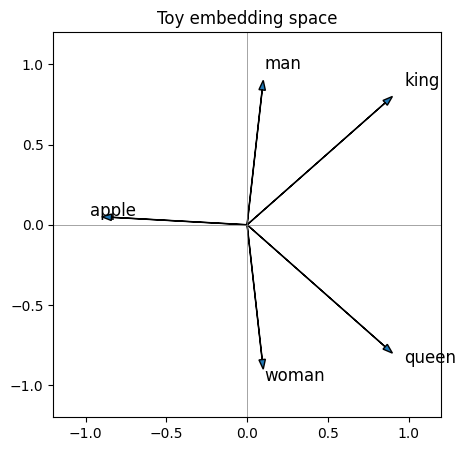

king - man + woman = [ 0.9 -1. ]    (queen is [ 0.9 -0.8] )


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# toy 2D "embeddings" — axis 0 = royalty-ness, axis 1 = maleness
words = {
    "king":   np.array([0.9, 0.8]),
    "queen":  np.array([0.9, -0.8]),
    "man":    np.array([0.1, 0.9]),
    "woman":  np.array([0.1, -0.9]),
    "apple":  np.array([-0.9, 0.05]),
}

fig, ax = plt.subplots(figsize=(5,5))
for w, v in words.items():
    ax.arrow(0, 0, v[0], v[1], head_width=0.04, length_includes_head=True)
    ax.text(v[0]*1.08, v[1]*1.08, w, fontsize=12)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title("Toy embedding space")
plt.show()

# the classic relationship: king - man + woman ≈ queen
result = words["king"] - words["man"] + words["woman"]
print("king - man + woman =", result, "   (queen is", words["queen"], ")")


Notice `apple` sits far away from the royalty/gender cluster — that's the
whole point. Real embedding models do this in 384, 768, or 1536+ dimensions
instead of 2, learned from data instead of hand-picked, but the idea is
identical: **meaning becomes distance and direction**.


## 2. Cosine similarity vs. dot product

- **Dot product**: `a · b = sum(a_i * b_i)`. Sensitive to vector *magnitude* —
  a longer vector can score higher even if it points in a less similar
  direction.
- **Cosine similarity**: `(a · b) / (|a| * |b|)`. Divides out the magnitude,
  so it only measures the *angle* between vectors — purely "how similar in
  direction," ignoring length.

If your embeddings are already L2-normalized (unit length), cosine similarity
and dot product give the **identical ranking** — this is why many vector DBs
just use dot product internally after normalizing vectors once, since it's
cheaper to compute.


In [4]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

a = np.array([1.0, 1.0])
b = np.array([2.0, 2.0])       # same direction as a, just longer
c = np.array([1.0, -1.0])      # perpendicular to a

print("dot(a,b)   =", np.dot(a, b))     # large — b is long
print("cos(a,b)   =", cosine_sim(a, b)) # 1.0 — same direction
print("dot(a,c)   =", np.dot(a, c))     # 0 — perpendicular
print("cos(a,c)   =", cosine_sim(a, c)) # 0.0

# now normalize a and b to unit length — dot product and cosine now agree
a_n = a / np.linalg.norm(a)
b_n = b / np.linalg.norm(b)
print("\nafter normalizing:")
print("dot(a_n,b_n) =", np.dot(a_n, b_n))
print("cos(a_n,b_n) =", cosine_sim(a_n, b_n))


dot(a,b)   = 4.0
cos(a,b)   = 0.9999999999999998
dot(a,c)   = 0.0
cos(a,c)   = 0.0

after normalizing:
dot(a_n,b_n) = 0.9999999999999998
cos(a_n,b_n) = 1.0


**Takeaway:** if two pieces of text differ mainly in *length* (a one-line
tweet vs. a long paragraph both "about cats"), dot product on raw embeddings
can be misleading — cosine similarity is the safer default for text search.
Most embedding models (including MiniLM and OpenAI's) are trained so that
cosine similarity is meaningful; some even ship pre-normalized.


## 3. Real embeddings

### Option A — open model, runs locally, free: `all-MiniLM-L6-v2`
384 dimensions, small and fast, a great default for learning and for small
projects.


In [5]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "The cat sat on the mat.",
    "A feline rested on the rug.",
    "The stock market fell sharply today.",
    "Investors were rattled by the market's steep decline.",
    "I love hiking in the mountains on weekends.",
]

embeddings = model.encode(sentences, normalize_embeddings=True)
print(embeddings.shape)  # (5, 384)

# similarity matrix
sim = embeddings @ embeddings.T   # dot product == cosine sim since normalized
import pandas as pd
print(pd.DataFrame(sim, index=[s[:20] for s in sentences],
                        columns=[s[:20] for s in sentences]).round(2))


/Users/sasidhars/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sasidhars/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(5, 384)
                      The cat sat on the m  A feline rested on t  \
The cat sat on the m                  1.00                  0.56   
A feline rested on t                  0.56                  1.00   
The stock market fel                  0.07                  0.06   
Investors were rattl                  0.02                 -0.04   
I love hiking in the                 -0.07                  0.01   

                      The stock market fel  Investors were rattl  \
The cat sat on the m                  0.07                  0.02   
A feline rested on t                  0.06                 -0.04   
The stock market fel                  1.00                  0.55   
Investors were rattl                  0.55                  1.00   
I love hiking in the                  0.02                  0.05   

                      I love hiking in the  
The cat sat on the m                 -0.07  
A feline rested on t                  0.01  
The stock market fel                  

Run that and look at the matrix: sentence 0 & 1 (cat/feline) should score
high with each other, 2 & 3 (stock market) should score high with each
other, and both pairs should score low against sentence 4 (hiking) — even
though none of the sentences share many exact words. That's the whole value
of embeddings over keyword search.

### Option B — OpenAI's `text-embedding-3-small` (needs an API key, costs a
fraction of a cent per call)


In [6]:
# import os
# from openai import OpenAI
# client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# resp = client.embeddings.create(
#     model="text-embedding-3-small",
#     input=sentences,
# )
# openai_embeddings = np.array([d.embedding for d in resp.data])
# print(openai_embeddings.shape)  # (5, 1536)

# OpenAI's vectors are also unit-normalized, so dot product == cosine here too.


## 4. Vector indexes: why you need one, and how they differ

With a handful of vectors, comparing your query to every single one
("brute force" / "flat" search) is instant. At a million+ vectors, brute
force is too slow for interactive use, so approximate nearest-neighbor (ANN)
indexes trade a small amount of accuracy for a large amount of speed.

- **Flat (`IndexFlatIP` / `IndexFlatL2`)**: no indexing at all, just compares
  the query against every stored vector. Exact, but O(n) per query. Fine up
  to ~100k vectors, or as a ground-truth baseline to measure ANN recall
  against.
- **IVF (Inverted File Index)**: clusters the vector space into `nlist`
  buckets (via k-means) ahead of time. At query time, only searches the
  `nprobe` buckets closest to the query instead of everything — like looking
  only in the relevant chapters of a book instead of every page. Faster, but
  can miss neighbors that landed in a nearby-but-unsearched bucket.
- **HNSW (Hierarchical Navigable Small World)**: builds a multi-layer graph
  where each vector is linked to a handful of its neighbors. Search "hops"
  through the graph toward the query, getting closer each step — like a
  skip-list for vector space. Excellent recall/speed tradeoff and very
  popular in production vector DBs (Pinecone, Weaviate, Qdrant all use HNSW
  variants), but the graph uses more memory than IVF.

Rule of thumb: start with Flat, move to HNSW when you need it, reach for IVF
(or IVF+HNSW hybrids) mainly at large scale where HNSW's memory footprint
becomes a problem.


In [7]:
import faiss
import numpy as np

# reuse the MiniLM embeddings from above, or fake some data:
d = embeddings.shape[1] if 'embeddings' in dir() else 384
n = 10000
rng = np.random.default_rng(0)
data = rng.normal(size=(n, d)).astype("float32")
faiss.normalize_L2(data)   # unit-normalize so inner product == cosine sim
query = data[0:1]          # pretend the first vector is our query

# --- Flat: exact brute-force baseline ---
index_flat = faiss.IndexFlatIP(d)
index_flat.add(data)
D, I = index_flat.search(query, k=5)
print("Flat  results:", I[0])

# --- IVF: cluster then search a subset of clusters ---
nlist = 100
quantizer = faiss.IndexFlatIP(d)
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)
index_ivf.train(data)      # k-means clustering happens here
index_ivf.add(data)
index_ivf.nprobe = 10       # search 10 of the 100 clusters
D, I = index_ivf.search(query, k=5)
print("IVF   results:", I[0])

# --- HNSW: graph-based ANN ---
index_hnsw = faiss.IndexHNSWFlat(d, 32)   # 32 = neighbors per node (M)
index_hnsw.add(data)
D, I = index_hnsw.search(query, k=5)
print("HNSW  results:", I[0])


Flat  results: [   0 9829 2591  827 6321]
IVF   results: [   0 9829 2591 8394 4775]
HNSW  results: [   0 9829 2591  827 3044]


Try bumping `n` up to 200k+ and timing each `.search()` call — that's where
the difference between Flat and the ANN indexes becomes obvious. Also try
lowering `nprobe` on the IVF index or `efSearch` on HNSW
(`index_hnsw.hnsw.efSearch = 16`) and watch recall vs. speed trade off
against the Flat baseline.


## 5. Chunking strategies

This is the step people underrate most. A great embedding model and a great
index can't save you from bad chunks — split too big and you dilute the
signal with irrelevant text; split too small and you lose the context a
question needs. Let's compare four approaches on the same passage.


In [8]:
text = '''Retrieval-augmented generation combines a retriever with a language model.
The retriever finds relevant passages from a knowledge base, typically using
vector search over embeddings. Those passages are then inserted into the
model's context window alongside the user's question. This lets the model
answer using up-to-date or private information it was never trained on.
The quality of retrieval depends heavily on how documents were chunked before
indexing. Chunks that are too large dilute relevance signal, since a chunk
embedding averages the meaning of everything inside it. Chunks that are too
small lose surrounding context that a reader would need to make sense of them.
Most production systems land on a few hundred tokens per chunk, often with
some overlap between consecutive chunks so a sentence split across a boundary
still has context on both sides.'''


In [9]:
# --- 1. Fixed-size chunking: split every N characters, no awareness of structure ---
def fixed_size_chunks(text, size=200, overlap=0):
    chunks = []
    start = 0
    while start < len(text):
        chunks.append(text[start:start+size])
        start += size - overlap
    return chunks

for c in fixed_size_chunks(text, size=150):
    print(repr(c[:60]), "...")
    print("---")


'Retrieval-augmented generation combines a retriever with a l' ...
---
'g\nvector search over embeddings. Those passages are then ins' ...
---
'nswer using up-to-date or private information it was never t' ...
---
'ndexing. Chunks that are too large dilute relevance signal, ' ...
---
'small lose surrounding context that a reader would need to m' ...
---
'ith\nsome overlap between consecutive chunks so a sentence sp' ...
---


Notice fixed-size chunking will happily cut a sentence — or even a word —
right in half. It's the simplest to implement and fastest to run, and it's
a reasonable baseline, but it ignores the text's actual structure.


In [10]:
# --- 2. Sentence-based chunking: split on sentence boundaries, then group ---
import re

def sentence_chunks(text, max_chars=200):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    chunks, current = [], ""
    for s in sentences:
        if len(current) + len(s) <= max_chars:
            current = (current + " " + s).strip()
        else:
            if current:
                chunks.append(current)
            current = s
    if current:
        chunks.append(current)
    return chunks

for c in sentence_chunks(text):
    print(c)
    print("---")


Retrieval-augmented generation combines a retriever with a language model. The retriever finds relevant passages from a knowledge base, typically using
vector search over embeddings.
---
Those passages are then inserted into the
model's context window alongside the user's question. This lets the model
answer using up-to-date or private information it was never trained on.
---
The quality of retrieval depends heavily on how documents were chunked before
indexing.
---
Chunks that are too large dilute relevance signal, since a chunk
embedding averages the meaning of everything inside it.
---
Chunks that are too
small lose surrounding context that a reader would need to make sense of them.
---
Most production systems land on a few hundred tokens per chunk, often with
some overlap between consecutive chunks so a sentence split across a boundary
still has context on both sides.
---


In [11]:
# --- 3. Recursive character splitting: try to split on the biggest structural
#        separator first (paragraphs), fall back to smaller ones (sentences,
#        words) only where a chunk is still too big. This is the approach
#        LangChain's RecursiveCharacterTextSplitter popularized.
def recursive_split(text, max_chars=200, separators=None):
    if separators is None:
        separators = ["\n\n", "\n", ". ", " ", ""]
    sep = separators[0]
    if sep == "":
        # last resort: hard character split
        return [text[i:i+max_chars] for i in range(0, len(text), max_chars)]

    parts = text.split(sep)
    chunks, current = [], ""
    for p in parts:
        piece = p + sep
        if len(current) + len(piece) <= max_chars:
            current += piece
        else:
            if current:
                chunks.append(current.strip())
            if len(piece) > max_chars:
                # this single piece is still too big — recurse with a smaller separator
                chunks.extend(recursive_split(piece, max_chars, separators[1:]))
                current = ""
            else:
                current = piece
    if current.strip():
        chunks.append(current.strip())
    return chunks

for c in recursive_split(text, max_chars=200):
    print(c)
    print("---")


Retrieval-augmented generation combines a retriever with a language model.
The retriever finds relevant passages from a knowledge base, typically using
---
vector search over embeddings. Those passages are then inserted into the
model's context window alongside the user's question. This lets the model
---
answer using up-to-date or private information it was never trained on.
The quality of retrieval depends heavily on how documents were chunked before
---
indexing. Chunks that are too large dilute relevance signal, since a chunk
embedding averages the meaning of everything inside it. Chunks that are too
---
small lose surrounding context that a reader would need to make sense of them.
Most production systems land on a few hundred tokens per chunk, often with
---
some overlap between consecutive chunks so a sentence split across a boundary
still has context on both sides.
---


In [12]:
# --- 4. Semantic chunking: embed each sentence, split where consecutive
#        sentences' meaning shifts (low cosine similarity), not by size at all.
def semantic_chunks(text, model, similarity_threshold=0.5):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    embs = model.encode(sentences, normalize_embeddings=True)

    chunks, current = [], [sentences[0]]
    for i in range(1, len(sentences)):
        sim = float(embs[i] @ embs[i-1])
        if sim < similarity_threshold:
            chunks.append(" ".join(current))
            current = [sentences[i]]
        else:
            current.append(sentences[i])
    chunks.append(" ".join(current))
    return chunks

for c in semantic_chunks(text, model, similarity_threshold=0.45):
    print(c)
    print("---")


Retrieval-augmented generation combines a retriever with a language model. The retriever finds relevant passages from a knowledge base, typically using
vector search over embeddings.
---
Those passages are then inserted into the
model's context window alongside the user's question.
---
This lets the model
answer using up-to-date or private information it was never trained on.
---
The quality of retrieval depends heavily on how documents were chunked before
indexing. Chunks that are too large dilute relevance signal, since a chunk
embedding averages the meaning of everything inside it. Chunks that are too
small lose surrounding context that a reader would need to make sense of them. Most production systems land on a few hundred tokens per chunk, often with
some overlap between consecutive chunks so a sentence split across a boundary
still has context on both sides.
---


Semantic chunking is the most expensive (an embedding call per sentence) but
produces chunks that follow actual topic shifts instead of an arbitrary
character count — worth it for heterogeneous documents (long reports, mixed
FAQ pages), often overkill for short, uniform documents.

**Practical starting point:** recursive character splitting with ~300–500
token chunks and ~10–15% overlap is a solid default for most RAG projects.
Reach for semantic chunking when you notice retrieval quality suffering on
documents that mix multiple topics per page.


## 6. Putting it together: a tiny end-to-end retrieval example

Chunk a document, embed the chunks, index them with FAISS, embed a query,
and retrieve the best-matching chunk — the full pipeline in miniature.


In [13]:
doc = text  # reuse the RAG passage from section 5

chunks = recursive_split(doc, max_chars=200)
chunk_embeddings = model.encode(chunks, normalize_embeddings=True).astype("float32")

index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
index.add(chunk_embeddings)

query = "why does chunk size matter for retrieval quality?"
query_emb = model.encode([query], normalize_embeddings=True).astype("float32")

D, I = index.search(query_emb, k=2)
print("Query:", query, "\n")
for rank, (idx, score) in enumerate(zip(I[0], D[0])):
    print(f"#{rank+1}  (cosine sim={score:.3f})")
    print(chunks[idx])
    print("---")


Query: why does chunk size matter for retrieval quality? 

#1  (cosine sim=0.605)
indexing. Chunks that are too large dilute relevance signal, since a chunk
embedding averages the meaning of everything inside it. Chunks that are too
---
#2  (cosine sim=0.480)
answer using up-to-date or private information it was never trained on.
The quality of retrieval depends heavily on how documents were chunked before
---


That's the entire retrieval half of RAG: **chunk → embed → index → embed
query → nearest-neighbor search → return top-k chunks**. The generation half
is just handing those retrieved chunks to an LLM as context alongside the
original question.

### Where to go next
- Swap in real documents (PDFs, docs) and see how chunk boundaries interact
  with headers, bullet lists, and tables.
- Measure retrieval quality, not just vibes: build a small set of
  question → expected-chunk pairs and check whether the right chunk shows
  up in the top-k.
- Try `nprobe`/`efSearch` sweeps on a larger synthetic dataset to feel the
  speed/recall tradeoff for yourself before picking a vector DB.
